In [132]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
import matplotlib as mpl
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Arc
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

In [299]:
def draw_self_loop(ax, center, node_r,
                   side="left",
                   loop_r=None,
                   gap_deg=70,          # size of opening in the loop
                   head_len=0.25,       # arrowhead segment length as fraction of loop_r
                   lw=1.5, color="k",
                   arrowstyle="-|>", mutation_scale=15):
    """
    Draw a circular self-loop with a well-centered arrowhead.

    side: 'left', 'right', 'top', 'bottom'
    node_r: node radius in data units
    loop_r: loop radius in data units (defaults to ~1.2*node_r)
    gap_deg: opening in the loop (deg). Bigger -> more open.
    head_len: arrow segment length as fraction of loop radius.
    """
    center = np.asarray(center, dtype=float)
    loop_r = 1.2*node_r if loop_r is None else loop_r

    # Place loop center outside the node
    offset_mag = node_r + 0.7*loop_r
    offsets = {
        "left":   np.array([-offset_mag, 0.0]),
        "right":  np.array([+offset_mag, 0.0]),
        "top":    np.array([0.0, +offset_mag]),
        "bottom": np.array([0.0, -offset_mag]),
    }
    c_loop = center + offsets[side]

    # Choose arc angles so the loop sits "outside" and the gap faces the node
    # Also ensure direction is CCW from theta1 -> theta2 (matplotlib convention).
    if side == "left":
        theta1 = gap_deg/2
        theta2 = 360 - gap_deg/2
    elif side == "right":
        theta1 =  180+gap_deg/2
        theta2 = 180+360-gap_deg/2
    elif side == "top":
        theta1 =  -90+gap_deg/2
        theta2 = -90-gap_deg/2
    elif side == "bottom":
        mid = 270.0
    else:
        raise ValueError("side must be one of: left, right, top, bottom")

    # Put the GAP toward the node (i.e., pointing from loop center to node center)
    # The direction from loop center to node center is -offsets[side]
    # That direction corresponds exactly to angle 'mid' in our selection above.
    #theta_gap_center = mid

    #theta1 = theta_gap_center + gap_deg/2
    #theta2 = 360 - gap_deg/2#theta_gap_center + gap_deg/2# + 360  # ensure theta2 > theta1 for CCW arc

    # Draw the circular arc (almost full circle, with a gap)
    arc = Arc(c_loop, 2*loop_r, 2*loop_r,
              angle=0, theta1=theta1, theta2=theta2,
              lw=lw, color=color)
    ax.add_patch(arc)

    # Arrowhead: pick an endpoint on the arc away from the gap, on the "outer" side
    # We'll use the end at theta2 (CCW end). Use points ON the arc for perfect centering.
    t_end = np.deg2rad(theta2+5.0) #%360
    end = c_loop + (loop_r)*np.array([np.cos(t_end), np.sin(t_end)])

    # Step BACK along the arc (CCW direction means decreasing angle to go backward near theta2)
    L = head_len * loop_r +0.01
    d = L / loop_r  # radians

    t_back = t_end - d
    back = c_loop + loop_r*np.array([np.cos(t_back), np.sin(t_back)])

    head = FancyArrowPatch(
        back, end,
        arrowstyle=arrowstyle,
        mutation_scale=mutation_scale,
        lw=lw, color=color
    )
    ax.add_patch(head)


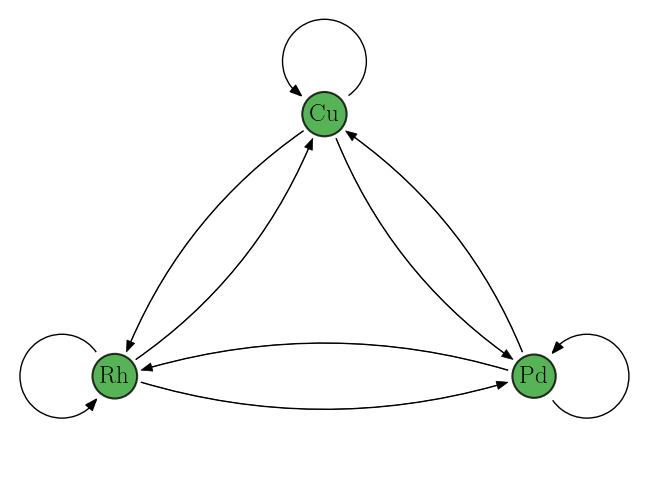

In [312]:
fig, ax = plt.subplots(layout="constrained")
ax.set_xlim([-0.2, 1.0])
ax.set_ylim([0.3, 1.2])
elements = ["Rh", "Pd", "Cu"]
positions = np.array([
    [0.0,0.5],
    [0.8,0.5],
    [0.4,1.0]
])

style = "Simple, tail_width=0.5, head_width=6, head_length=8"#"-|>, head_width=6, head_length=8, widthA=0.2, widthB=0.2"#, "Simple, tail_width=0.5, head_width=6, head_length=8"
arrowkw = dict(arrowstyle=style, color="k", linewidth=0.5)
spacing = 0.045
vert_spacing = -0.01
sides = ["left", "right", "top"]
for i, element, position in zip(range(len(elements)), elements, positions):
    bbox_params = dict(boxstyle="circle", facecolor="C2", alpha=0.8, lw=1.5)#FancyBboxPatch(xy=position, width=0.5, height=0.5, boxstyle="circle")
    ann = ax.text(x=position[0], y=position[1], s=element, fontdict={"fontsize":18, "va":"center", "ha":"center"})
    ann.set_bbox(bbox_params)
    #bbox = FancyBboxPatch(xy=position,width=0.5,height=0.5, **bbox_params)
    #plt.gca().add_patch(bbox)
    arrows = []
    for j in range(len(elements)):
        if i == j:
            draw_self_loop(ax=ax, center=position, node_r=spacing, side=sides[i], loop_r=0.08,lw=1.0, arrowstyle=style, mutation_scale=1.0)
        else:
            diff_pos = positions[j] - position
            diff_pos_hat = diff_pos/np.linalg.norm(diff_pos)
            spacing_vec = np.array([-diff_pos_hat[1], diff_pos_hat[0]])
            arrow = FancyArrowPatch(posA=position+diff_pos_hat*spacing+vert_spacing*spacing_vec, posB=positions[j]-diff_pos_hat*spacing+vert_spacing*spacing_vec, connectionstyle="arc3,rad=.15", **arrowkw)
            arrows.append(arrow)
    for arrow in arrows:
        plt.gca().add_patch(arrow)

ax.axis("off")
ax.set_aspect("equal")
plt.savefig("stochastic_process.pdf", bbox_inches='tight')